Original image shape: (1080, 1920, 3)


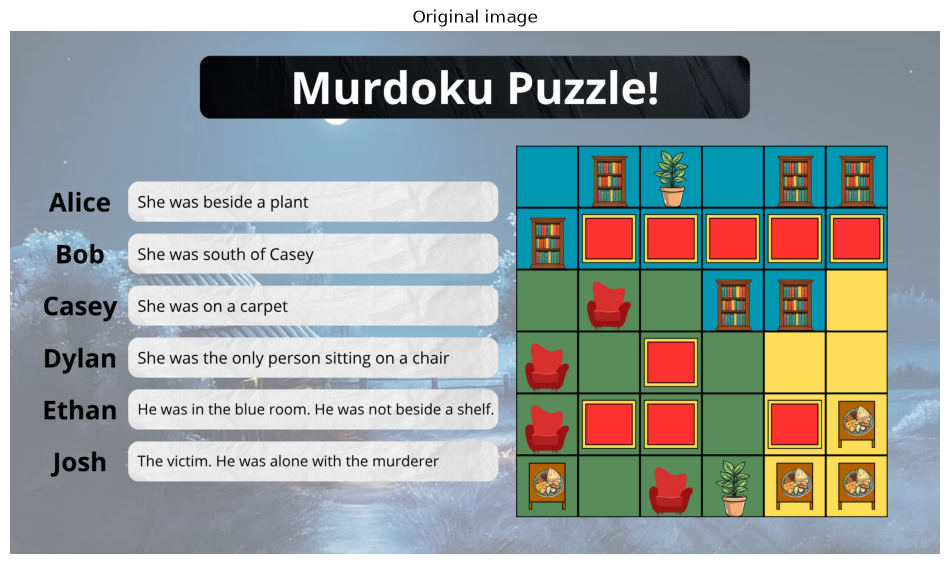

Clue region shape: (1080, 1020, 3)


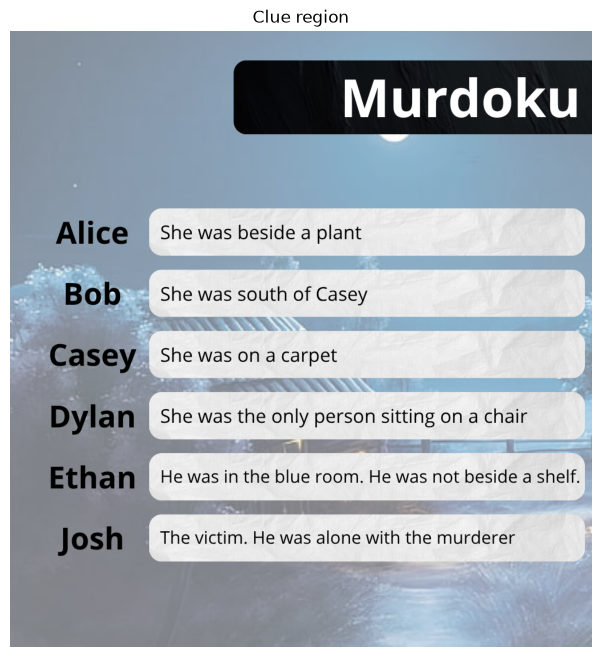

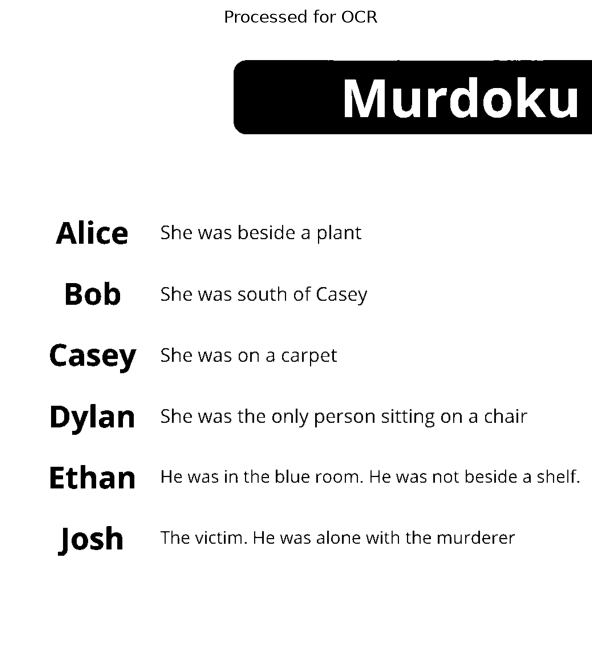


========== RAW OCR ==========

._ Murdoku
Alice She was beside a plant
Bob She was south of Casey
Casey She was on a carpet
Dylan She was the only person sitting on a chair
Ethan He was in the blue room. He was not beside a shelf.
Josh The victim. He was alone with the murderer


========== WORD CONFIDENCES ==========

'._'                      confidence=0.0
'Murdoku'                 confidence=14.0
'Alice'                   confidence=89.0
'She'                     confidence=33.0
'was'                     confidence=92.0
'beside'                  confidence=91.0
'a'                       confidence=91.0
'plant'                   confidence=93.0
'Bob'                     confidence=96.0
'She'                     confidence=96.0
'was'                     confidence=95.0
'south'                   confidence=95.0
'of'                      confidence=95.0
'Casey'                   confidence=96.0
'Casey'                   confidence=96.0
'She'                     confidence=96.0
'was'  

In [ ]:
import cv2
import pytesseract
import matplotlib.pyplot as plt


# =========================
# CONFIG
# =========================

IMAGE_PATH = "data/puzzle2.png"

# Crop coordinates:
# image[y1:y2, x1:x2]
Y1 = 0
Y2 = 1080
X1 = 0
X2 = 1020

MIN_CONFIDENCE = 50


# =========================
# FUNCTIONS
# =========================

def show_image(image, title="", gray=False):
    plt.figure(figsize=(12, 8))

    if gray:
        plt.imshow(image, cmap="gray")
    else:
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

    plt.title(title)
    plt.axis("off")
    plt.show()


def crop_clue_region(image):
    return image[Y1:Y2, X1:X2]


def preprocess_for_ocr(image):
    gray = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )

    _, binary = cv2.threshold(
        gray,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    return binary


# =========================
# LOAD IMAGE
# =========================

image = cv2.imread(IMAGE_PATH)

if image is None:
    raise FileNotFoundError(
        f"Could not load image: {IMAGE_PATH}"
    )

print("Original image shape:", image.shape)

show_image(
    image,
    "Original image"
)


# =========================
# CROP CLUE REGION
# =========================

clue_region = crop_clue_region(image)

print("Clue region shape:", clue_region.shape)

show_image(
    clue_region,
    "Clue region"
)


# =========================
# PREPROCESS
# =========================

processed = preprocess_for_ocr(
    clue_region
)

show_image(
    processed,
    "Processed for OCR",
    gray=True
)


# =========================
# RAW OCR
# =========================

raw_text = pytesseract.image_to_string(
    processed,
    config="--psm 6"
)

print("\n========== RAW OCR ==========\n")
print(raw_text)


# =========================
# OCR WITH CONFIDENCE
# =========================

data = pytesseract.image_to_data(
    processed,
    config="--psm 6",
    output_type=pytesseract.Output.DICT
)

accepted_words = []

print("\n========== WORD CONFIDENCES ==========\n")

for i, text in enumerate(data["text"]):
    text = text.strip()

    if not text:
        continue

    confidence = float(
        data["conf"][i]
    )

    print(
        f"{text!r:25} confidence={confidence:.1f}"
    )

    if confidence >= MIN_CONFIDENCE:
        accepted_words.append(text)


# =========================
# FILTERED RESULT
# =========================

filtered_text = " ".join(
    accepted_words
)

print("\n========== FILTERED OCR ==========\n")
print(filtered_text)